In [1]:
!pip install pandas matplotlib seaborn --quiet

In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
pd.set_option("display.max_rows", 10)

sns.set(style="whitegrid")



print("Setup complete")

Setup complete


In [4]:
from google. colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from google.colab import files

import pandas as pd

uploaded = files.upload()


Saving student.csv to student.csv


In [6]:
full_path = '/content/student.csv'

In [7]:
#Exercise 1: Loading and Exploring the Data

In [8]:
#Passing CSV through pandas
df = pd.read_csv('/content/student.csv')


In [9]:
#View first 5 rows
df.head()

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


In [10]:
#Display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      35 non-null     int64 
 1   name    34 non-null     object
 2   class   34 non-null     object
 3   mark    35 non-null     int64 
 4   gender  33 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.5+ KB


In [11]:
#Summary Statistics
df.describe()

,id,mark
count,35.000000,35.000000
mean,18.000000,74.657143
std,10.246951,16.401117
min,1.000000,18.000000
25%,9.500000,62.500000
50%,18.000000,79.000000
75%,26.500000,88.000000
max,35.000000,96.000000


In [12]:
#Excerise 2 Indexing and Slicing

In [13]:
#Viewing names column only
df['name'].head() #first 5 names

,name
0,John Deo
1,Max Ruin
2,Arnold
3,Krish Star
4,John Mike


In [14]:
#Viewing name and mark column
df[['name', 'mark']].head() #first 5

,name,mark
0,John Deo,75
1,Max Ruin,85
2,Arnold,55
3,Krish Star,60
4,John Mike,60


In [15]:
#Select first 3 rows
df.head(3)

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male


In [16]:
#Select rows where class is 4
df[df['class']=='Four']

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female
5,6,Alex John,Four,55,male
9,10,Big John,Four,55,female
15,16,Gimmy,Four,88,male
20,21,Babby John,Four,69,female
30,31,Marry Toeey,Four,88,male


In [17]:
#Exercise 3: Data Manipulation

In [18]:
#Students passed if score was greater than or equal to 60
df['passed'] = df['mark'] >= 60

In [19]:
#Rename mark to score
df = df.rename(columns = {
    'mark':'score'
})

In [20]:
#Drop passed column
df = df.drop(columns = {'passed'})

In [21]:
df.head()

,id,name,class,score,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


In [22]:
#Exercise 4: Aggregation and Grouping

In [23]:
#Group by class and score and calculate the mean score
df.groupby('class')['score'].mean()

,score
class,
Eight,79.000000
Fifth,78.000000
Five,80.000000
Four,68.750000
Nine,41.500000
Seven,77.600000
Six,82.571429
Three,73.666667


In [24]:
#Students per class
df.groupby('class')['score'].count()

,score
class,
Eight,1
Fifth,1
Five,2
Four,8
Nine,2
Seven,10
Six,7
Three,3


In [25]:
#Gender by mean score
df.groupby('gender')['score'].mean()

,score
gender,
female,77.312500
male,71.588235


In [26]:
#Exercise 5: Advanced Operationals

In [27]:
#Create a pivot table
pivot = df.pivot_table(index=['class'], #row
                       columns=['gender'], #columns
                       values=['score']) #values
print(pivot)

        score      
gender female  male
class              
Eight     NaN  79.0
Fifth     NaN  78.0
Five      NaN  80.0
Four     63.8  77.0
Nine     65.0  18.0
Seven    81.4  73.8
Six      89.2  54.0
Three     NaN  70.0


In [28]:
#New column 'grade' where marks >= 85 are 'A', 70-85 are 'B', 60-69 are 'C, below 60 are 'D'
df['grade'] = pd.cut(
    df['score'],
    bins=[0,59,69,84,100],
    labels=['D','C','B','A']
)

df.head()

,id,name,class,score,gender,grade
0,1,John Deo,Four,75,female,B
1,2,Max Ruin,Three,85,male,A
2,3,Arnold,Three,55,male,D
3,4,Krish Star,Four,60,female,C
4,5,John Mike,Four,60,female,C


In [29]:
#Sort 'score' by descending order
df.sort_values(by='score', ascending=False)

,id,name,class,score,gender,grade
32,33,Kenn Rein,Six,96,female,A
11,12,Recky,Six,94,female,A
31,32,Binn Rott,Seven,90,female,A
10,11,Ronald,Six,89,female,A
30,31,Marry Toeey,Four,88,male,A
...,...,...,...,...,...,...
9,10,Big John,Four,55,female,D
21,22,Reggid,Seven,55,female,D
28,29,Tess Played,Seven,55,male,D
16,17,Tumyu,Six,54,male,D


In [30]:
#Exercise 6: Exporting Data

In [31]:
#Saving data to a CSV file
df.to_csv('updated_students') #file named 'updated_students'

In [32]:
#Exercise 7: Visualisation

In [33]:
from google.colab import files

import pandas as pd

uploaded = files.upload()

Saving student.csv to student (1).csv


<Axes: xlabel='class'>

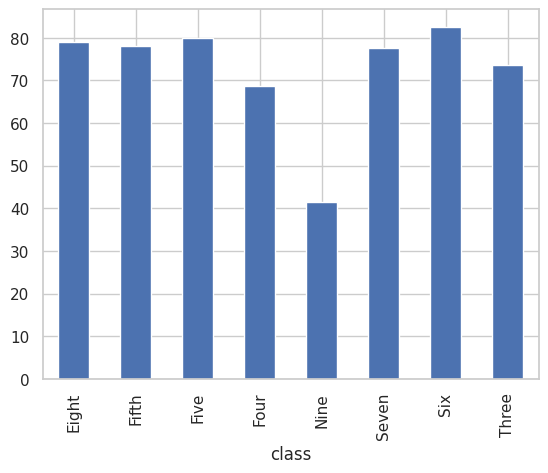

In [34]:
#Plot visualisation using group by to combine students per class
df.groupby('class')['score'].mean().plot(kind='bar') #.mean() to get average score per class

<Axes: title={'center': 'score'}, xlabel='gender'>

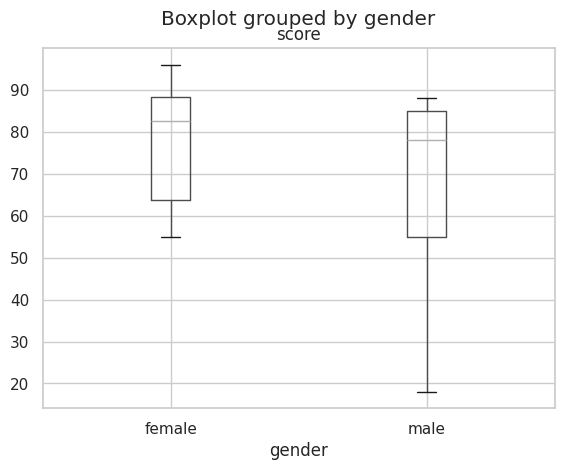

In [35]:
#Box Plot Visualisation grouped by gender
df.boxplot(column='score', by='gender')

In [36]:
df.iloc[:, 0] #id

,id
0,1
1,2
2,3
3,4
4,5
...,...
30,31
31,32
32,33
33,34


In [37]:
df.iloc[:, 2] #class

,class
0,Four
1,Three
2,Three
3,Four
4,Four
...,...
30,Four
31,Seven
32,Six
33,Seven


In [38]:
df.iloc [[0, 3, 5]]

,id,name,class,score,gender,grade
0,1,John Deo,Four,75,female,B
3,4,Krish Star,Four,60,female,C
5,6,Alex John,Four,55,male,D


In [43]:
from IPython.core.display import Markdown
from os import name

class Student:
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def passed(self, threshold):
        return self.score >= threshold


threshold_mark = 75
students = []

for index, row in df.iterrows():
    s = Student(row['name'], row['score'])   # FIXED
    students.append(s)

pass_count = 0
fail_count = 0

for s in students:
    result = s.passed(threshold_mark)
    print(s.name, s.score, result)

    if result:                               # FIXED
        pass_count += 1
    else:
        fail_count += 1

print("\nTotal Passed (True):", pass_count)
print("Total Failed (False):", fail_count)

true_rows = [s for s in students if s.passed(threshold_mark)]
false_rows = [s for s in students if not s.passed(threshold_mark)]

print("Passed:")
for s in true_rows:
    print(s.name, s.score)

print("\nFailed:")
for s in false_rows:
    print(s.name, s.score)



John Deo 75 True
Max Ruin 85 True
Arnold 55 False
Krish Star 60 False
John Mike 60 False
Alex John 55 False
My John Rob 78 True
Asruid 85 True
Tes Qry 78 True
Big John 55 False
Ronald 89 True
Recky 94 True
Kty 88 True
Bigy 88 True
Tade Row 88 True
Gimmy 88 True
Tumyu 54 False
Honny 75 True
Tinny 18 False
Jackly 65 False
Babby John 69 False
Reggid 55 False
Herod 79 True
Tiddy Now 78 True
Giff Tow 88 True
Crelea 79 True
nan 81 True
Rojj Base 86 True
Tess Played 55 False
Reppy Red 79 True
Marry Toeey 88 True
Binn Rott 90 True
Kenn Rein 96 True
Gain Toe 69 False
Rows Noump 88 True

Total Passed (True): 23
Total Failed (False): 12
Passed:
John Deo 75
Max Ruin 85
My John Rob 78
Asruid 85
Tes Qry 78
Ronald 89
Recky 94
Kty 88
Bigy 88
Tade Row 88
Gimmy 88
Honny 75
Herod 79
Tiddy Now 78
Giff Tow 88
Crelea 79
nan 81
Rojj Base 86
Reppy Red 79
Marry Toeey 88
Binn Rott 90
Kenn Rein 96
Rows Noump 88

Failed:
Arnold 55
Krish Star 60
John Mike 60
Alex John 55
Big John 55
Tumyu 54
Tinny 18
Jackly 65
Bab

In [46]:
true_rows = [s for s in students if s.passed(threshold_mark)]
false_rows = [s for s in students if not s.passed(threshold_mark)]

print("Passed:")
for s in true_rows:
    print(s.name, s.score)

print("\nFailed:")
for s in false_rows:
    print(s.name, s.score)

Passed:
John Deo 75
Max Ruin 85
My John Rob 78
Asruid 85
Tes Qry 78
Ronald 89
Recky 94
Kty 88
Bigy 88
Tade Row 88
Gimmy 88
Honny 75
Herod 79
Tiddy Now 78
Giff Tow 88
Crelea 79
nan 81
Rojj Base 86
Reppy Red 79
Marry Toeey 88
Binn Rott 90
Kenn Rein 96
Rows Noump 88

Failed:
Arnold 55
Krish Star 60
John Mike 60
Alex John 55
Big John 55
Tumyu 54
Tinny 18
Jackly 65
Babby John 69
Reggid 55
Tess Played 55
Gain Toe 69


In [47]:
df.head()

,id,name,class,score,gender,grade
0,1,John Deo,Four,75,female,B
1,2,Max Ruin,Three,85,male,A
2,3,Arnold,Three,55,male,D
3,4,Krish Star,Four,60,female,C
4,5,John Mike,Four,60,female,C


In [49]:
#filtering
df[df['score']> 80].head()

,id,name,class,score,gender,grade
1,2,Max Ruin,Three,85,male,A
7,8,Asruid,Five,85,male,A
10,11,Ronald,Six,89,female,A
11,12,Recky,Six,94,female,A
12,13,Kty,Seven,88,female,A


In [50]:
df[(df['score']> 80) &(df['gender']=='female')].head()

,id,name,class,score,gender,grade
10,11,Ronald,Six,89,female,A
11,12,Recky,Six,94,female,A
12,13,Kty,Seven,88,female,A
13,14,Bigy,Seven,88,female,A
27,28,Rojj Base,Seven,86,female,A


In [51]:
df[df['score']>80|(df['class']=='Four')].head()

,id,name,class,score,gender,grade
0,1,John Deo,Four,75,female,B
1,2,Max Ruin,Three,85,male,A
2,3,Arnold,Three,55,male,D
3,4,Krish Star,Four,60,female,C
4,5,John Mike,Four,60,female,C


In [52]:
df.head()

,id,name,class,score,gender,grade
0,1,John Deo,Four,75,female,B
1,2,Max Ruin,Three,85,male,A
2,3,Arnold,Three,55,male,D
3,4,Krish Star,Four,60,female,C
4,5,John Mike,Four,60,female,C


In [54]:
#Read a csv file into pandas DataFrame
import pandas as pd
df = pd.read_csv('/content/student.csv')


In [55]:
#Display first 5
df.head()

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


In [56]:
#Display info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      35 non-null     int64 
 1   name    34 non-null     object
 2   class   34 non-null     object
 3   mark    35 non-null     int64 
 4   gender  33 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.5+ KB


In [57]:
#Describe
df.describe()

,id,mark
count,35.000000,35.000000
mean,18.000000,74.657143
std,10.246951,16.401117
min,1.000000,18.000000
25%,9.500000,62.500000
50%,18.000000,79.000000
75%,26.500000,88.000000
max,35.000000,96.000000


In [58]:
#Select a name from a coloumn
df['name'].head()

,name
0,John Deo
1,Max Ruin
2,Arnold
3,Krish Star
4,John Mike


In [59]:
#name and marks
df[['name', 'mark']].head()

,name,mark
0,John Deo,75
1,Max Ruin,85
2,Arnold,55
3,Krish Star,60
4,John Mike,60


In [60]:
#first 3 rows
df.iloc[0:3]

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male


In [61]:
#rows where 'class' is 'Four'
df[df['class'] == 'Four']

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female
5,6,Alex John,Four,55,male
9,10,Big John,Four,55,female
15,16,Gimmy,Four,88,male
20,21,Babby John,Four,69,female
30,31,Marry Toeey,Four,88,male


In [62]:
df['passed'] = df['mark'] >= 60

In [63]:
df = df.rename(columns={
    'mark':'score'
})

In [64]:
df = df.drop(columns = {'passed'})

In [65]:
df.head()

,id,name,class,score,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


In [66]:
df.groupby('class')['score'].mean()

,score
class,
Eight,79.000000
Fifth,78.000000
Five,80.000000
Four,68.750000
Nine,41.500000
Seven,77.600000
Six,82.571429
Three,73.666667


In [67]:
df.groupby('class')['score'].count()

,score
class,
Eight,1
Fifth,1
Five,2
Four,8
Nine,2
Seven,10
Six,7
Three,3


In [68]:
df.groupby('gender')['score'].mean()

,score
gender,
female,77.312500
male,71.588235


In [71]:
#Create a pivot table with 'class' as rows, 'gender' as columns and 'score' as values
pivot = df.pivot_table(
    index='class',
    columns='gender',
    values='score'
)
print(pivot)


gender  female  male
class               
Eight      NaN  79.0
Fifth      NaN  78.0
Five       NaN  80.0
Four      63.8  77.0
Nine      65.0  18.0
Seven     81.4  73.8
Six       89.2  54.0
Three      NaN  70.0
